In [4]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_curve, auc, confusion_matrix, balanced_accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import seaborn as sns
import gc
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
import pandas as pd
import shutil
from collections import defaultdict

# Set GPU memory growth to avoid allocating all memory at once
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Set GPU memory growth
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Found {len(gpus)} GPU devices and enabled memory growth")
    except RuntimeError as e:
        print(f"GPU setup error: {e}")


SEED = 3888
def set_seed(seed=3888):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
set_seed(SEED)

# Define image size and batch size
IMG_SIZE = 224  # Standard input size for VGG16
BATCH_SIZE = 32

Found 1 GPU devices and enabled memory growth


In [3]:
type_to_label_map = {
    'Empty': 0,
    'Non-Tumor': 1,
    'Tumor': 2
}

In [6]:
def create_vgg16_model(learning_rate=0.0001, input_shape=(224, 224, 3), seed=3888):
    K.clear_session()
    set_seed(seed)

    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False  # Freeze base layers initially

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )
    return model


=== Fold 1: Testing on Q1 ===
Found 3196 images belonging to 3 classes.
Found 1050 images belonging to 3 classes.
Epoch 1/20
100/100 [==============================] - ETA: 0s - loss: 0.7785 - accuracy: 0.6192
Epoch 1: val_accuracy improved from -inf to 0.80381, saving model to vgg16_fold_1_gen.h5
100/100 [==============================] - 38s 374ms/step - loss: 0.7785 - accuracy: 0.6192 - val_loss: 0.4901 - val_accuracy: 0.8038
Epoch 2/20
100/100 [==============================] - ETA: 0s - loss: 0.5545 - accuracy: 0.7544
Epoch 2: val_accuracy did not improve from 0.80381
100/100 [==============================] - 38s 383ms/step - loss: 0.5545 - accuracy: 0.7544 - val_loss: 0.4498 - val_accuracy: 0.7848
Epoch 3/20
100/100 [==============================] - ETA: 0s - loss: 0.5242 - accuracy: 0.7672
Epoch 3: val_accuracy improved from 0.80381 to 0.80476, saving model to vgg16_fold_1_gen.h5
100/100 [==============================] - 35s 355ms/step - loss: 0.5242 - accuracy: 0.7672 - val

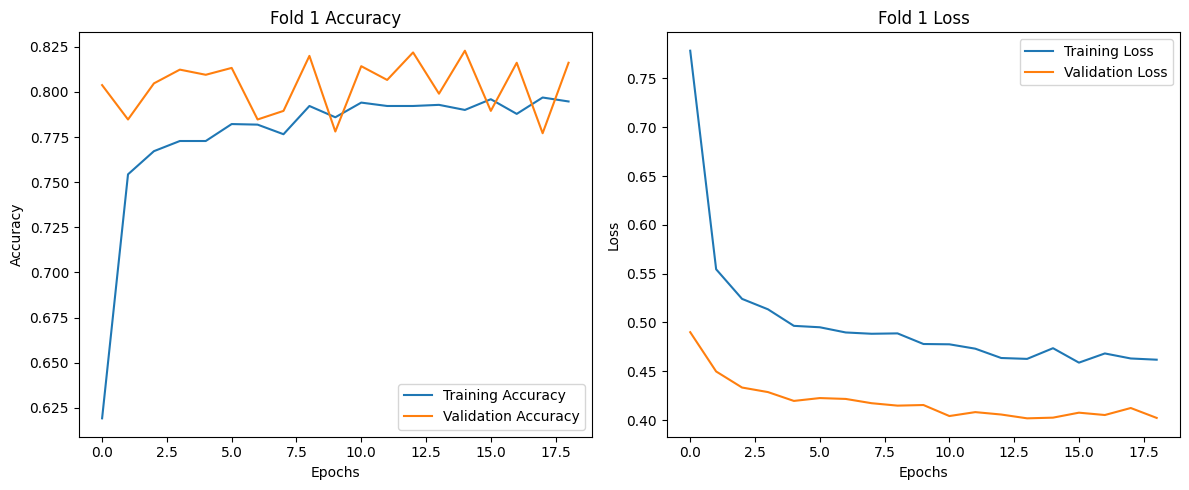


=== Fold 2: Testing on Q2 ===
Found 3256 images belonging to 3 classes.
Found 990 images belonging to 3 classes.
Epoch 1/20
102/102 [==============================] - ETA: 0s - loss: 0.8014 - accuracy: 0.6170
Epoch 1: val_accuracy improved from -inf to 0.82121, saving model to vgg16_fold_2_gen.h5
102/102 [==============================] - 38s 370ms/step - loss: 0.8014 - accuracy: 0.6170 - val_loss: 0.4764 - val_accuracy: 0.8212
Epoch 2/20
102/102 [==============================] - ETA: 0s - loss: 0.5592 - accuracy: 0.7518
Epoch 2: val_accuracy improved from 0.82121 to 0.83434, saving model to vgg16_fold_2_gen.h5
102/102 [==============================] - 40s 393ms/step - loss: 0.5592 - accuracy: 0.7518 - val_loss: 0.4201 - val_accuracy: 0.8343
Epoch 3/20
102/102 [==============================] - ETA: 0s - loss: 0.5271 - accuracy: 0.7632
Epoch 3: val_accuracy did not improve from 0.83434
102/102 [==============================] - 37s 365ms/step - loss: 0.5271 - accuracy: 0.7632 - val_

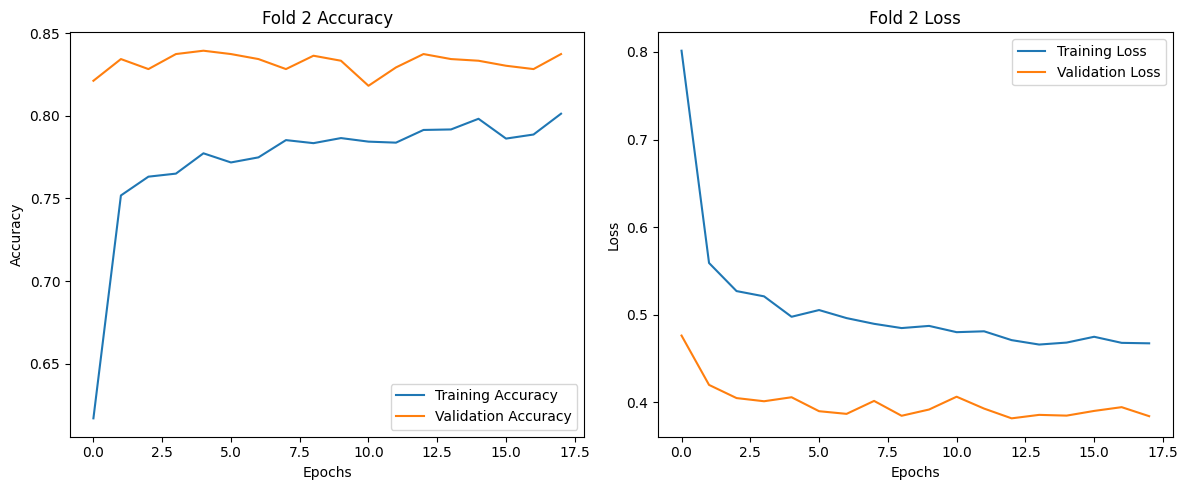


=== Fold 3: Testing on Q3 ===
Found 3143 images belonging to 3 classes.
Found 1103 images belonging to 3 classes.
Epoch 1/20
99/99 [==============================] - ETA: 0s - loss: 0.7651 - accuracy: 0.6322
Epoch 1: val_accuracy improved from -inf to 0.74977, saving model to vgg16_fold_3_gen.h5
99/99 [==============================] - 39s 393ms/step - loss: 0.7651 - accuracy: 0.6322 - val_loss: 0.5483 - val_accuracy: 0.7498
Epoch 2/20
99/99 [==============================] - ETA: 0s - loss: 0.5231 - accuracy: 0.7709
Epoch 2: val_accuracy improved from 0.74977 to 0.76700, saving model to vgg16_fold_3_gen.h5
99/99 [==============================] - 38s 387ms/step - loss: 0.5231 - accuracy: 0.7709 - val_loss: 0.4995 - val_accuracy: 0.7670
Epoch 3/20
99/99 [==============================] - ETA: 0s - loss: 0.4947 - accuracy: 0.7865
Epoch 3: val_accuracy did not improve from 0.76700
99/99 [==============================] - 37s 374ms/step - loss: 0.4947 - accuracy: 0.7865 - val_loss: 0.503

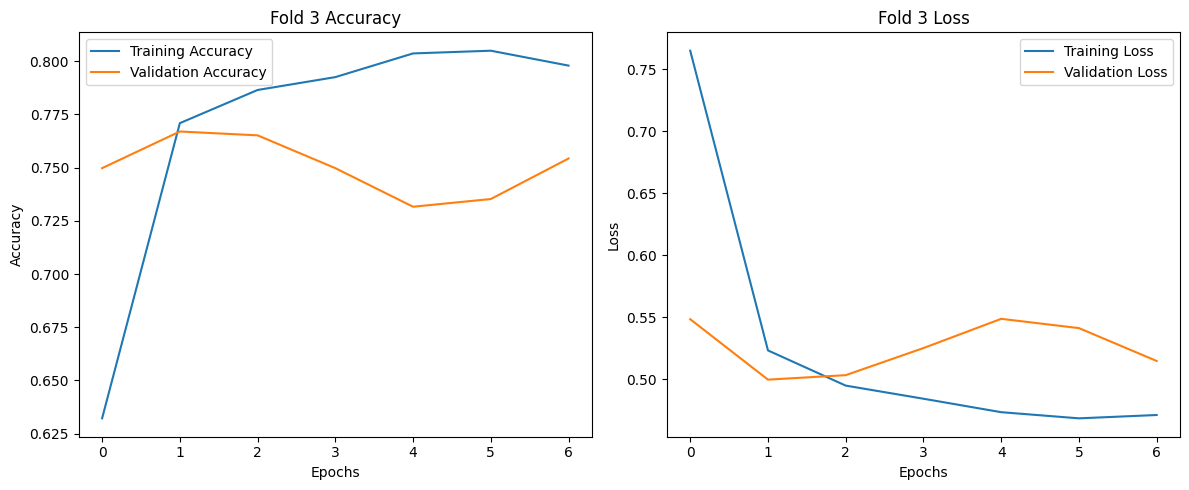


=== Fold 4: Testing on Q4 ===
Found 3143 images belonging to 3 classes.
Found 1103 images belonging to 3 classes.
Epoch 1/20
99/99 [==============================] - ETA: 0s - loss: 0.7708 - accuracy: 0.6201
Epoch 1: val_accuracy improved from -inf to 0.76972, saving model to vgg16_fold_4_gen.h5
99/99 [==============================] - 38s 377ms/step - loss: 0.7708 - accuracy: 0.6201 - val_loss: 0.5515 - val_accuracy: 0.7697
Epoch 2/20
99/99 [==============================] - ETA: 0s - loss: 0.5243 - accuracy: 0.7588
Epoch 2: val_accuracy improved from 0.76972 to 0.78241, saving model to vgg16_fold_4_gen.h5
99/99 [==============================] - 40s 401ms/step - loss: 0.5243 - accuracy: 0.7588 - val_loss: 0.5290 - val_accuracy: 0.7824
Epoch 3/20
99/99 [==============================] - ETA: 0s - loss: 0.4892 - accuracy: 0.7763
Epoch 3: val_accuracy improved from 0.78241 to 0.78876, saving model to vgg16_fold_4_gen.h5
99/99 [==============================] - 36s 369ms/step - loss: 0.

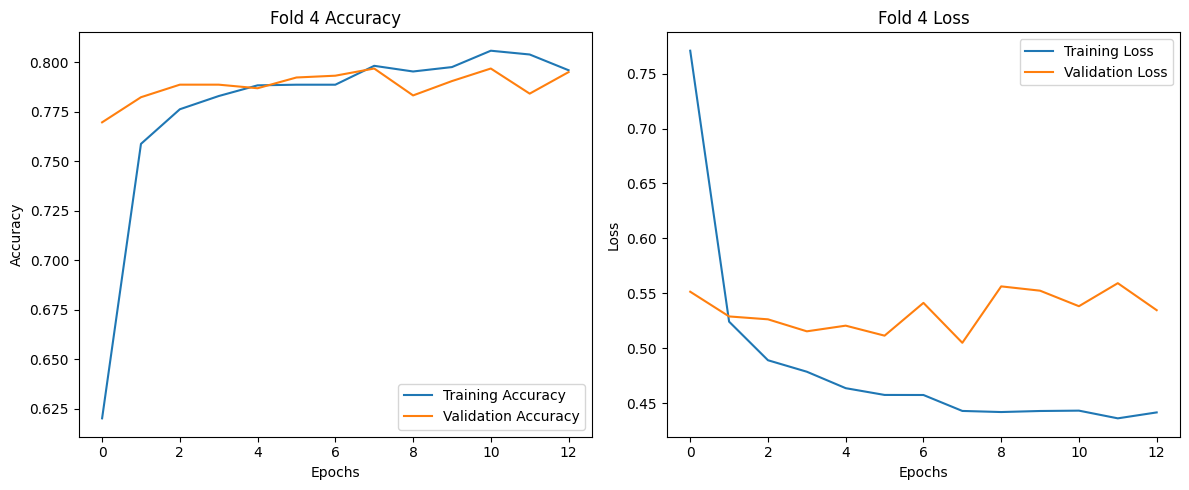


VGG16 model training completed


In [9]:
import tempfile
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = "projectdata/images/100_stratified4fold_1000per_seed3888"
quadrants = ["Q1", "Q2", "Q3", "Q4"]
img_size = (224, 224)  
batch_size = 32
epochs = 20


def merge_training_dirs(train_dirs):
    temp_dir = tempfile.mkdtemp()
    class_names = ['Empty', 'Non-Tumor', 'Tumor']
    for class_name in class_names:
        os.makedirs(os.path.join(temp_dir, class_name), exist_ok=True)
    for train_dir in train_dirs:
        for class_name in class_names:
            src_dir = os.path.join(train_dir, class_name)
            dst_dir = os.path.join(temp_dir, class_name)
            for file in os.listdir(src_dir):
                shutil.copy(os.path.join(src_dir, file), dst_dir)
    return temp_dir

train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=10, zoom_range=0.1)
test_datagen = ImageDataGenerator(rescale=1./255)

for i, test_fold in enumerate(quadrants):
    set_seed(SEED)
    print(f"\n=== Fold {i+1}: Testing on {test_fold} ===")
    train_folds = [q for q in quadrants if q != test_fold]
    train_dirs = [os.path.join(base_dir, fold) for fold in train_folds]
    valid_dir = os.path.join(base_dir, test_fold)

    merged_train_dir = merge_training_dirs(train_dirs)

    train_generator = train_datagen.flow_from_directory(
        merged_train_dir, target_size=img_size, batch_size=batch_size,
        class_mode='categorical'
    )

    val_generator = test_datagen.flow_from_directory(
        valid_dir, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', shuffle=False
    )

    model = create_vgg16_model(learning_rate=0.001, input_shape=(224, 224, 3), seed=SEED)

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True)
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        f'vgg16_fold_{i+1}_gen.h5', monitor='val_accuracy', save_best_only=True, verbose=1)

    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=val_generator,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Fold {i+1} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Fold {i+1} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    K.clear_session()
    gc.collect()

print("\nVGG16 model training completed")